In [1]:
import xarray as xr
import hvplot.xarray
from datetime import datetime
import panel as pn

In [2]:
import pandas as pd

# Get the current date and time
stop_time= pd.Timestamp.now()

# Subtract 10 days using pd.DateOffset
start_time = stop_time - pd.DateOffset(days=3)

print(f"Start Time: {start_time}")
print(f"Stop Time: {stop_time}")

Start Time: 2026-04-20 14:57:08.618808
Stop Time: 2026-04-23 14:57:08.618808


In [3]:
dap_url = 'http://thredds.socib.es/thredds/dodsC/operational_models/oceanographical/hydrodynamics/model_run_aggregation/wmop_surface/wmop_surface_best.ncd'

In [4]:
ds = xr.open_dataset(dap_url)

In [5]:
# Variabili disponibili nel dataset
ds

<xarray.Dataset> Size: 349GB
Dimensions:      (time: 36662, lat_rho: 539, lon_rho: 631, lat_uv: 539,
                  lon_uv: 631, ocean_time: 25)
Coordinates:
  * ocean_time   (ocean_time) datetime64[ns] 200B 2026-04-14 ... 2026-04-17
  * lat_rho      (lat_rho) float64 4kB 34.9 34.92 34.94 ... 44.68 44.7 44.71
  * lon_rho      (lon_rho) float64 5kB -5.8 -5.776 -5.752 ... 9.152 9.176 9.2
  * lat_uv       (lat_uv) float64 4kB 34.9 34.92 34.94 ... 44.68 44.7 44.71
  * lon_uv       (lon_uv) float64 5kB -5.8 -5.776 -5.752 ... 9.152 9.176 9.2
  * time         (time) datetime64[ns] 293kB 2013-08-27 ... 2026-04-26
    time_run     (time) datetime64[ns] 293kB ...
Data variables:
    time_offset  (time) datetime64[ns] 293kB ...
    temp         (time, lat_rho, lon_rho) float32 50GB ...
    salt         (time, lat_rho, lon_rho) float32 50GB ...
    zeta         (time, lat_rho, lon_rho) float32 50GB ...
    u            (time, lat_uv, lon_uv) float32 50GB ...
    v            (time, lat_uv, lon_uv) float32 50GB ...
    ubar         (time, lat_uv, lon_uv) float32 50GB ...
    vbar         (time, lat_uv, lon_uv) float32 50GB ...
Attributes: (12/16)
    file:                            WMOP surface his file
    version:                         WMOPv2.2r ROMS Forecast (with data assim...
    format:                          netCDF-3 classic file
    Conventions:                     CF-1.4
    institution:                     SOCIB
    fullname:                        Balearic Islands Coastal Observing and F...
    ...                              ...
    _CoordSysBuilder:                ucar.nc2.dataset.conv.CF1Convention
    cdm_data_type:                   GRID
    featureType:                     GRID
    location:                        Proto fmrc:wmop_surface
    history:                         FMRC Best Dataset
    DODS_EXTRA.Unlimited_Dimension:  ocean_time

In [6]:
%%time
# Correnti superficiali 21-31 marzo 2026
u = ds['u'].sel(time=slice('2026-03-21', '2026-03-31')).load()
v = ds['v'].sel(time=slice('2026-03-21', '2026-03-31')).load()
print(u)
print(v)

<xarray.DataArray 'u' (time: 88, lat_uv: 539, lon_uv: 631)> Size: 120MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, 

# Mappe di Circolazione Superficiale - WMOP SOCIB\n## Media giornaliera per 21 marzo e 31 marzo 2026

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Carica il dataset se non già in memoria
try:
    u
    v
except NameError:
    dap_url = 'http://thredds.socib.es/thredds/dodsC/operational_models/oceanographical/hydrodynamics/model_run_aggregation/wmop_surface/wmop_surface_best.ncd'
    ds = xr.open_dataset(dap_url)
    u = ds['u'].sel(time=slice('2026-03-21', '2026-03-31')).load()
    v = ds['v'].sel(time=slice('2026-03-21', '2026-03-31')).load()

LON = slice(2.0, 6.5)
LAT = slice(41.0, 44.5)
DATES = ['2026-03-21', '2026-03-31']
TITLES = ['21 March 2026', '31 March 2026']

datasets = []
for date in DATES:
    u_day = u.sel(time=date).mean(dim='time').sel(lon_uv=LON, lat_uv=LAT)
    v_day = v.sel(time=date).mean(dim='time').sel(lon_uv=LON, lat_uv=LAT)
    spd   = np.sqrt(u_day**2 + v_day**2)
    datasets.append({'u': u_day, 'v': v_day, 'spd': spd})

vmin   = float(min(d['spd'].min() for d in datasets))
vmax   = float(max(d['spd'].max() for d in datasets))
levels = np.linspace(vmin, vmax, 70)

print(f"vmin={vmin:.4f}  vmax={vmax:.4f} m/s")
print(f"Griglia: {datasets[0]['u'].lon_uv.size} lon × {datasets[0]['u'].lat_uv.size} lat")

vmin=0.0008  vmax=0.9259 m/s
Griglia: 189 lon × 200 lat


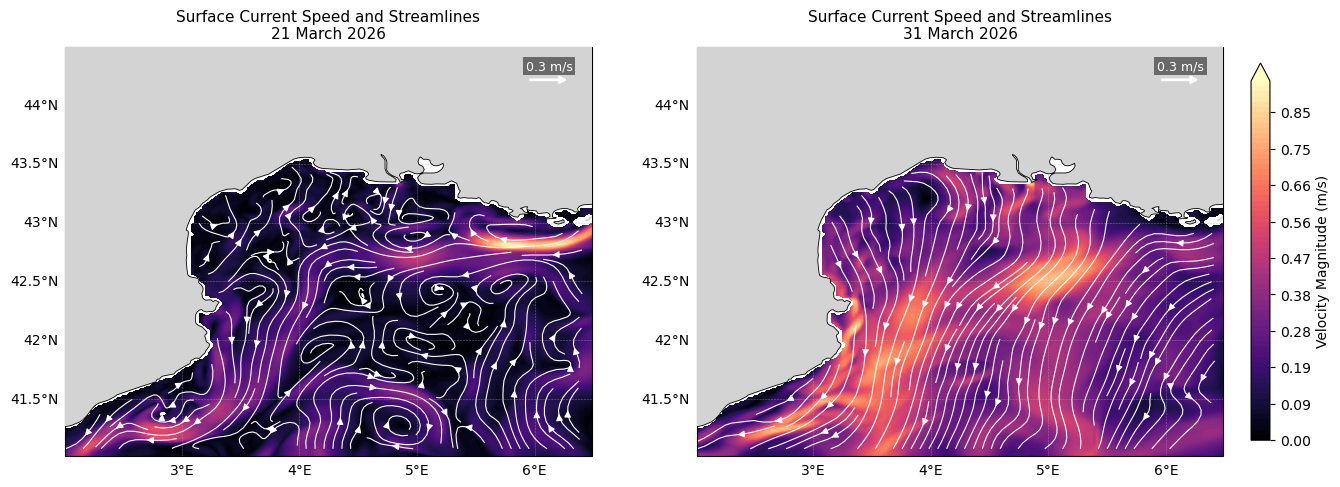

Figura salvata in /home/jovyan/LAR/circolazione_21_31_marzo_2026.png


In [8]:
lon = datasets[0]['u'].lon_uv.values
lat = datasets[0]['u'].lat_uv.values

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

for ax, data, title in zip(axes, datasets, TITLES):
    cf = ax.contourf(
        lon, lat, data['spd'].values,
        levels=levels,
        cmap='magma',
        transform=ccrs.PlateCarree(),
        extend='max',
    )

    ax.streamplot(
        lon, lat, data['u'].values, data['v'].values,
        transform=ccrs.PlateCarree(),
        density=2,
        linewidth=0.8,
        color='white',
        arrowsize=1.0,
    )

    # Vettore di riferimento 0.3 m/s
    ref_speed = 0.30
    lon_extent = lon.max() - lon.min()
    arrow_len = (ref_speed / vmax) * lon_extent * 0.25
    ref_lon = lon.max() - arrow_len * 1.5
    ref_lat = lat.max() - (lat.max() - lat.min()) * 0.08
    ax.annotate('',
                xy=(ref_lon + arrow_len, ref_lat),
                xytext=(ref_lon, ref_lat),
                xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color='white', lw=2),
                zorder=5)
    ax.text(ref_lon + arrow_len / 2, ref_lat + (lat.max() - lat.min()) * 0.025,
            '0.3 m/s', color='white', ha='center', fontsize=9,
            transform=ccrs.PlateCarree(),
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2),
            zorder=5)

    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
    gl.right_labels = False
    gl.top_labels = False
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    ax.set_title(f'Surface Current Speed and Streamlines\n{title}', fontsize=11)

cbar = fig.colorbar(cf, ax=axes, label='Velocity Magnitude (m/s)', shrink=0.7, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

out_path = '/home/jovyan/LAR/circolazione_21_31_marzo_2026.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in {out_path}")

## Comparazione Temperatura: WMOP vs CMEMS MED PHY\n### Potential temperature superficiale – 21 e 31 marzo 2026

INFO - 2026-04-23T14:57:44Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  lfortunato


Copernicus Marine password:

  ········


INFO - 2026-04-23T14:58:17Z - Selected dataset version: "202511"
INFO - 2026-04-23T14:58:17Z - Selected dataset part: "default"


Scala colore condivisa: 12.22 – 15.45 °C


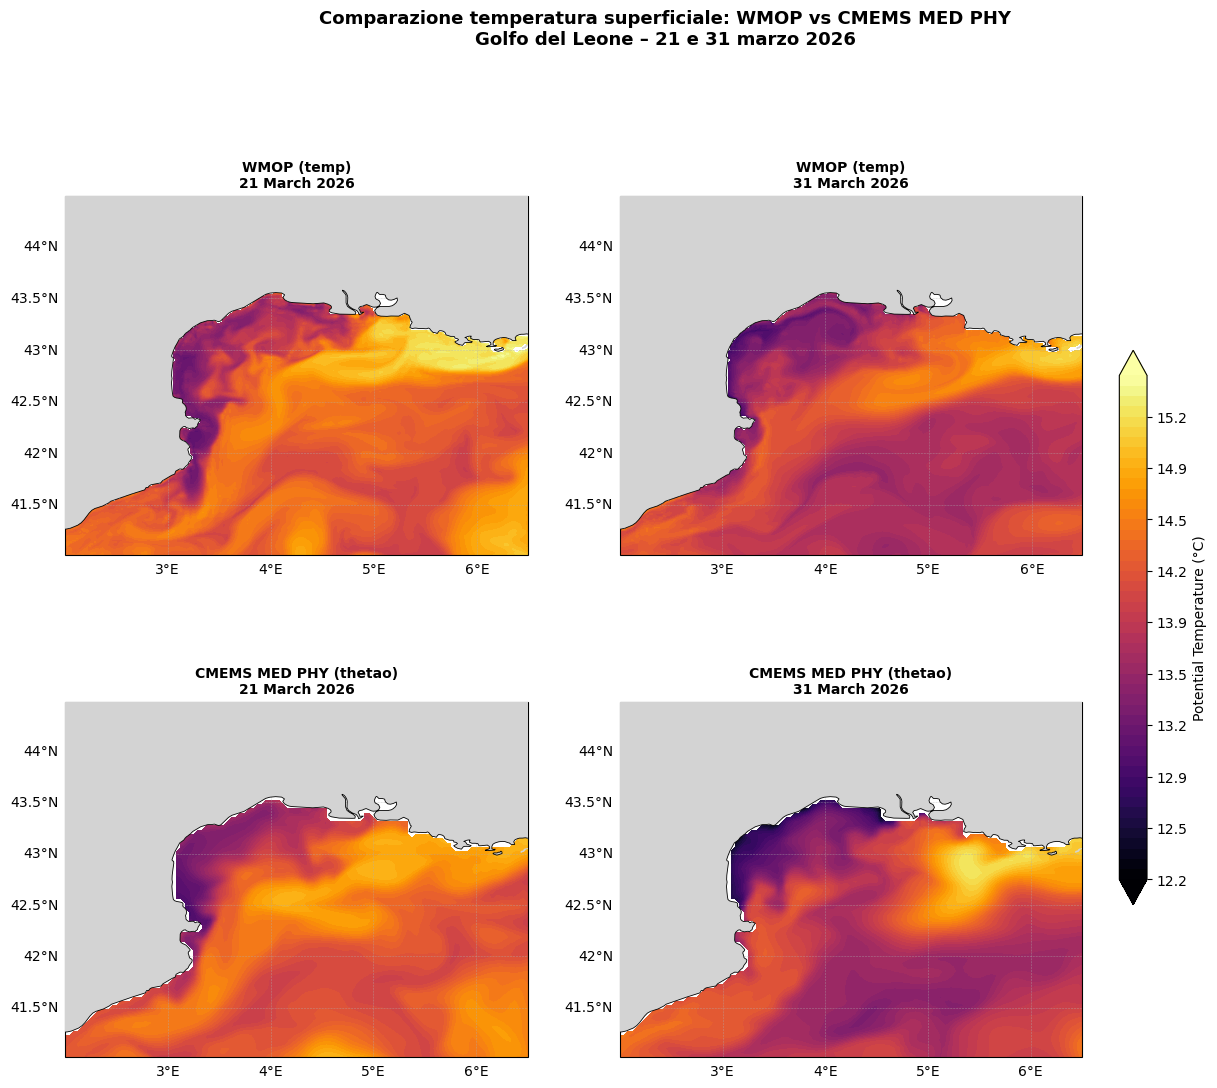

Figura salvata in /home/jovyan/LAR/comparazione_temperatura_21_31_marzo_2026.png


In [9]:
import copernicusmarine
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

DATES  = ['2026-03-21', '2026-03-31']
TITLES = ['21 March 2026', '31 March 2026']
LON = slice(2.0, 6.5)
LAT = slice(41.0, 44.5)

# --- WMOP: temperatura superficiale (media giornaliera) ---
try:
    ds
except NameError:
    dap_url = 'http://thredds.socib.es/thredds/dodsC/operational_models/oceanographical/hydrodynamics/model_run_aggregation/wmop_surface/wmop_surface_best.ncd'
    ds = xr.open_dataset(dap_url)

wmop_data = []
for date in DATES:
    temp_day = (
        ds['temp']
        .sel(time=date)
        .mean(dim='time')
        .sel(lon_rho=LON, lat_rho=LAT)
        .load()
    )
    wmop_data.append(temp_day)

# --- CMEMS MED PHY: thetao superficiale ---
ds_cmems = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-temp_my_4.2km_P1D-m')

cmems_data = []
for date in DATES:
    thetao = (
        ds_cmems['thetao']
        .sel(depth=0, time=date, method='nearest')
        .sel(longitude=LON, latitude=LAT)
        .load()
    )
    cmems_data.append(thetao)

# --- Scala colore comune sui 4 pannelli ---
vmin = float(min(d.min() for d in wmop_data + cmems_data))
vmax = float(max(d.max() for d in wmop_data + cmems_data))
levels = np.linspace(vmin, vmax, 50)
print(f"Scala colore condivisa: {vmin:.2f} – {vmax:.2f} °C")

# --- Plot: 2 righe (WMOP / CMEMS) × 2 colonne (21 / 31 marzo) ---
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

row_labels = ['WMOP', 'CMEMS']
all_data   = [wmop_data, cmems_data]
lon_keys   = [wmop_data[0].lon_rho.values, cmems_data[0].longitude.values]
lat_keys   = [wmop_data[0].lat_rho.values, cmems_data[0].latitude.values]

for row, (row_data, lons, lats, row_label) in enumerate(
        zip(all_data, lon_keys, lat_keys, row_labels)):
    for col, (da_t, title) in enumerate(zip(row_data, TITLES)):
        ax = axes[row, col]
        cf = ax.contourf(
            lons, lats, da_t.values,
            levels=levels,
            cmap='inferno',
            transform=ccrs.PlateCarree(),
            extend='both',
        )
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
        gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
        gl.right_labels = False
        gl.top_labels   = False
        ax.set_extent([float(lons.min()), float(lons.max()),
                       float(lats.min()), float(lats.max())],
                      crs=ccrs.PlateCarree())
        ax.set_title(f'{row_label}\n{title}', fontsize=10, fontweight='bold')

cbar = fig.colorbar(cf, ax=axes, label='Potential Temperature (°C)',
                    shrink=0.6, pad=0.03, orientation='vertical')
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

fig.suptitle('Temperature Comparison: WMOP vs CMEMS \Gulf of Lion',
             fontsize=13, fontweight='bold', y=1.01)

out_path = '/home/jovyan/LAR/comparazione_temperatura_21_31_marzo_2026.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in {out_path}")

## Comparazione Salinità: WMOP vs CMEMS MED PHY\n### Practical salinity superficiale – 21 e 31 marzo 2026

INFO - 2026-04-23T15:06:20Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  lfortunato


Copernicus Marine password:

  ········


INFO - 2026-04-23T15:06:29Z - Selected dataset version: "202511"
INFO - 2026-04-23T15:06:29Z - Selected dataset part: "default"


Scala colore condivisa: 21.511 – 38.639 PSU


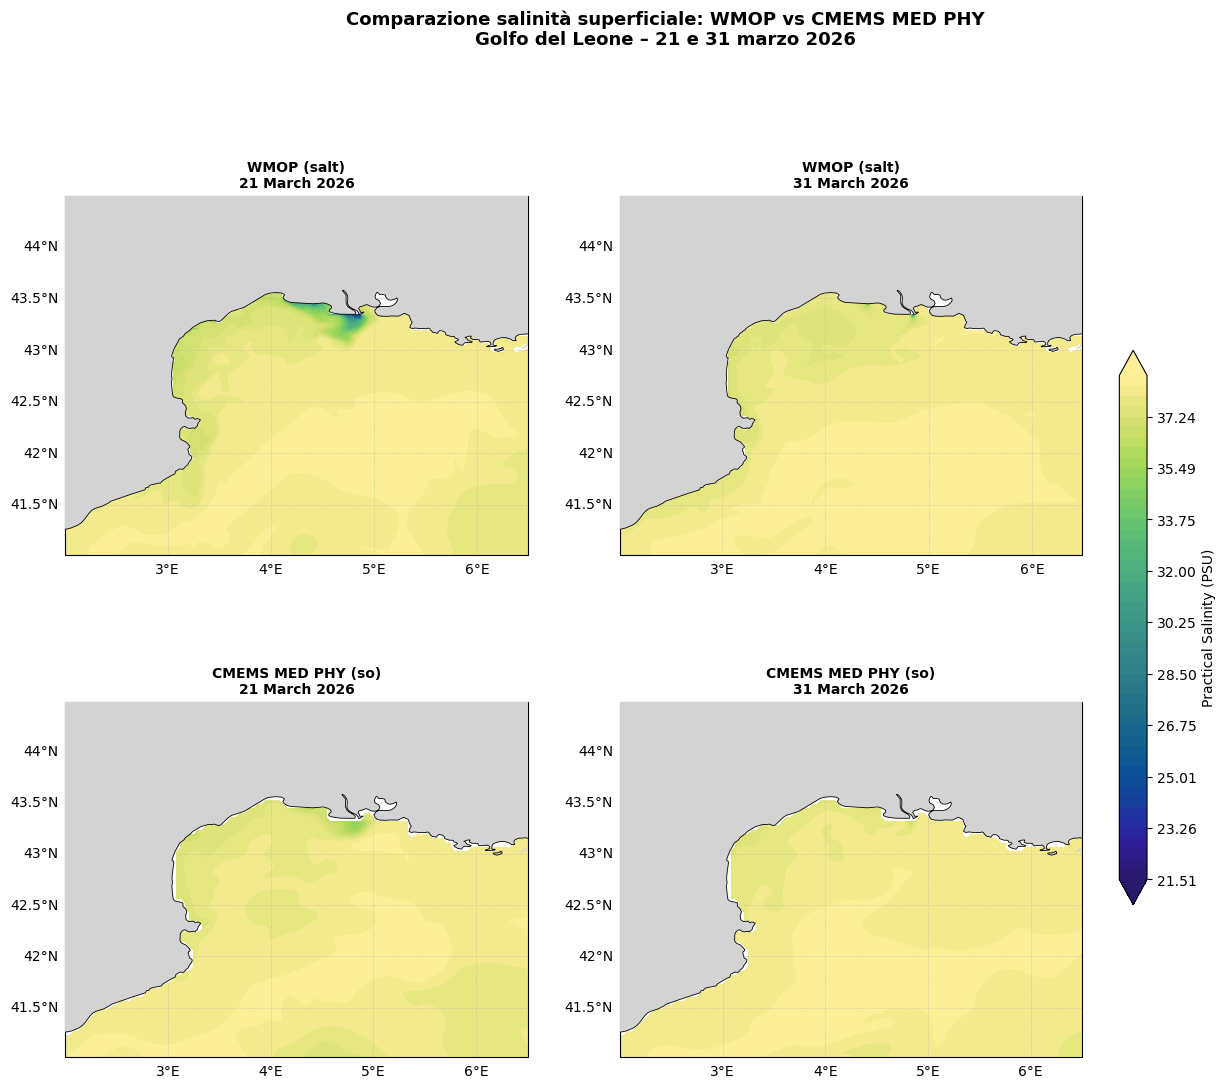

Figura salvata in /home/jovyan/LAR/comparazione_salinita_21_31_marzo_2026.png


In [10]:
import copernicusmarine
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import numpy as np
import xarray as xr

DATES  = ['2026-03-21', '2026-03-31']
TITLES = ['21 March 2026', '31 March 2026']
LON = slice(2.0, 6.5)
LAT = slice(41.0, 44.5)

# --- WMOP: salinità superficiale (media giornaliera) ---
try:
    ds
except NameError:
    dap_url = 'http://thredds.socib.es/thredds/dodsC/operational_models/oceanographical/hydrodynamics/model_run_aggregation/wmop_surface/wmop_surface_best.ncd'
    ds = xr.open_dataset(dap_url)

wmop_sal = []
for date in DATES:
    salt_day = (
        ds['salt']
        .sel(time=date)
        .mean(dim='time')
        .sel(lon_rho=LON, lat_rho=LAT)
        .load()
    )
    wmop_sal.append(salt_day)

# --- CMEMS MED PHY: so superficiale ---
ds_sal = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-sal_my_4.2km_P1D-m')

cmems_sal = []
for date in DATES:
    so = (
        ds_sal['so']
        .sel(depth=0, time=date, method='nearest')
        .sel(longitude=LON, latitude=LAT)
        .load()
    )
    cmems_sal.append(so)

# --- Scala colore comune sui 4 pannelli ---
vmin = float(min(d.min() for d in wmop_sal + cmems_sal))
vmax = float(max(d.max() for d in wmop_sal + cmems_sal))
levels = np.linspace(vmin, vmax, 50)
print(f"Scala colore condivisa: {vmin:.3f} – {vmax:.3f} PSU")

# --- Plot: 2 righe (WMOP / CMEMS) × 2 colonne (21 / 31 marzo) ---
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

row_labels = ['WMOP (salt)', 'CMEMS MED PHY (so)']
all_data   = [wmop_sal, cmems_sal]
lon_keys   = [wmop_sal[0].lon_rho.values, cmems_sal[0].longitude.values]
lat_keys   = [wmop_sal[0].lat_rho.values, cmems_sal[0].latitude.values]

for row, (row_data, lons, lats, row_label) in enumerate(
        zip(all_data, lon_keys, lat_keys, row_labels)):
    for col, (da_t, title) in enumerate(zip(row_data, TITLES)):
        ax = axes[row, col]
        cf = ax.contourf(
            lons, lats, da_t.values,
            levels=levels,
            cmap='cmo.haline',
            transform=ccrs.PlateCarree(),
            extend='both',
        )
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
        gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
        gl.right_labels = False
        gl.top_labels   = False
        ax.set_extent([float(lons.min()), float(lons.max()),
                       float(lats.min()), float(lats.max())],
                      crs=ccrs.PlateCarree())
        ax.set_title(f'{row_label}\n{title}', fontsize=10, fontweight='bold')

cbar = fig.colorbar(cf, ax=axes, label='Practical Salinity (PSU)',
                    shrink=0.6, pad=0.03, orientation='vertical')
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

fig.suptitle('Comparazione salinità superficiale: WMOP vs CMEMS MED PHY\nGolfo del Leone – 21 e 31 marzo 2026',
             fontsize=13, fontweight='bold', y=1.01)

out_path = '/home/jovyan/LAR/comparazione_salinita_21_31_marzo_2026.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in {out_path}")